# Unsupervised Machine Learning
## Clustering & Dimensionality Reduction Report

**Iris Dataset — K-Means, DBSCAN, Hierarchical Clustering, PCA & t-SNE**

| | |
|---|---|
| **Course** | Data Science Practicum, Spring 2026 |
| **Dataset** | UCI Iris Dataset (Fisher, 1936) |
| **Date** | March 2026 |
| **Stack** | Python 3.11 · scikit-learn 1.4 · pandas · matplotlib · scipy |

---

## Table of Contents

1. [Dataset Selection and Description](#1-dataset-selection-and-description)
2. [Analytical Approach and Model Development](#2-analytical-approach-and-model-development)
3. [Results and Evaluation](#3-results-and-evaluation)
4. [Key Findings and Visualizations](#4-key-findings-and-visualizations)
5. [Limitations and Future Work](#5-limitations-and-future-work)
6. [Appendix](#appendix)


---
# 1. Dataset Selection and Description

## 1.1 Dataset Overview

The Iris dataset is one of the most well-known benchmark datasets in the machine learning and statistics community. Originally introduced by Ronald A. Fisher in his 1936 paper *"The Use of Multiple Measurements in Taxonomic Problems,"* it has become a foundational example for both supervised and unsupervised algorithm development.

**Key distinction for this report:** Labels are **withheld during model training entirely**. Algorithms receive only the four numeric measurements and must discover natural groupings from the data alone. True labels are used only at the evaluation stage to validate how well discovered clusters correspond to biological species.

Available from:
- UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/53/iris
- Scikit-learn built-in: `sklearn.datasets.load_iris()`
- Kaggle: https://www.kaggle.com/datasets/uciml/iris

## 1.2 Dataset Characteristics

*Note: The dataset is identical to the Supervised Classification Report. Only the task type differs — labels are withheld from all models here.*

| **Attribute** | **Value** |
|---|---|
| Total Samples | 150 |
| Features (Inputs) | 4 numeric, continuous |
| True Classes (withheld from models) | 3 (Iris species) |
| Samples per Class | 50 (perfectly balanced) |
| Missing Values | None |
| Data Type | Multivariate, real-valued |
| Task Type | Unsupervised clustering + dimensionality reduction |
| Year Introduced | 1936 (Fisher) |

## 1.3 Features (Input Variables)

| **#** | **Feature Name** | **Description** | **Unit** | **Range (approx.)** |
|---|---|---|---|---|
| 1 | sepal_length | Length of the sepal (outer leaf-like structure) | cm | 4.3 – 7.9 |
| 2 | sepal_width | Width of the sepal | cm | 2.0 – 4.4 |
| 3 | petal_length | Length of the petal (inner flower structure) | cm | 1.0 – 6.9 |
| 4 | petal_width | Width of the petal | cm | 0.1 – 2.5 |

## 1.4 Target Variable (Validation Only)

| **Class** | **Species** | **Description** | **Count** |
|---|---|---|---|
| 0 | *Iris setosa* | Distinctly separable; very small petals | 50 |
| 1 | *Iris versicolor* | Intermediate species; overlaps with virginica | 50 |
| 2 | *Iris virginica* | Largest flowers; partially overlaps versicolor | 50 |

## 1.5 Relevance to Unsupervised Learning

- **Known ground truth for validation:** External metrics (ARI, NMI) can be computed — ordinarily unavailable in real deployments.
- **Partial overlap challenge:** Setosa is trivially separable; versicolor and virginica share overlapping petal measurements.
- **Low dimensionality:** PCA reduces to 2D retaining 95.6% of variance — enabling direct visual inspection.
- **No preprocessing burden:** No missing values, no categorical encoding.

> In a real-world context, this clustering is analogous to customer segmentation, cell-type discovery in single-cell genomics, or anomaly group detection in cybersecurity.


---
# 2. Analytical Approach and Model Development

## 2.1 Environment Setup

All code is written in Python 3.11. Install dependencies before running:

```
pip install scikit-learn pandas numpy matplotlib seaborn scipy umap-learn
```


In [1]:
# ── 2.1 Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score,
                              adjusted_rand_score,
                              normalized_mutual_info_score,
                              homogeneity_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

print("All libraries imported successfully.")


All libraries imported successfully.


## 2.2 Data Loading and Exploration

### 2.2.1 Loading the Dataset

Labels are loaded but **immediately withheld** from clustering models. They are stored separately for post-hoc validation only.


In [2]:
# ── 2.2.1 Load Dataset — labels WITHHELD from clustering ─────────────────
iris = load_iris()
X             = iris.data           # Feature matrix (150, 4) — what models see
y_true        = iris.target         # True labels (150,) — used ONLY for validation
feature_names = iris.feature_names
species_names = iris.target_names

# Wrap features in DataFrame for exploration
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y_true              # kept separate, never passed to clustering

print(f"Feature matrix shape: {X.shape}")   # (150, 4)
print(f"Species: {species_names}")           # [setosa, versicolor, virginica]
print(f"Note: y_true not passed to any clustering algorithm during training")
print()
print(df.head())


Feature matrix shape: (150, 4)
Species: ['setosa' 'versicolor' 'virginica']
Note: y_true not passed to any clustering algorithm during training

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [25]:
y_true

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### 2.2.2 Descriptive Statistics


In [3]:
# ── 2.2.2 Descriptive Statistics ─────────────────────────────────────────
print(df[feature_names].describe().round(2))


       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  
count            150.00  
mean               1.20  
std                0.76  
min                0.10  
25%                0.30  
50%                1.30  
75%                1.80  
max                2.50  


**Key Observation:** Petal features show dramatically higher standard deviation than sepal features, suggesting they carry more discriminating information for clustering.

### 2.2.3 Correlation Analysis


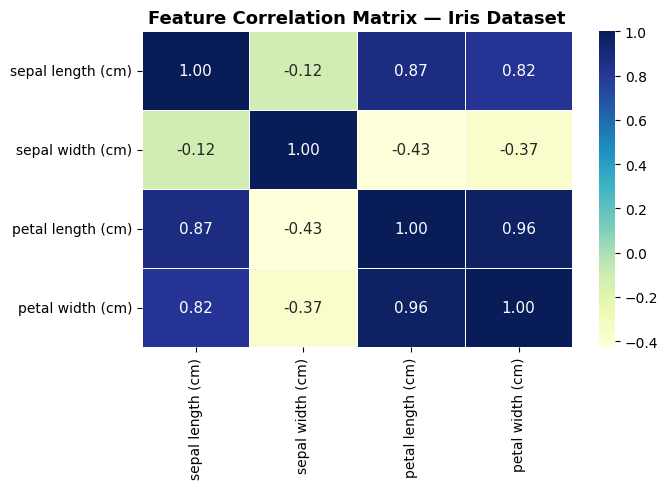


Key correlations:
  petal_length ↔ petal_width:  r = 0.963  (very strong)
  sepal_length ↔ petal_length: r = 0.872  (strong)
  sepal_width  ↔ petal_length: r = -0.428  (weak negative)


In [4]:
# ── 2.2.3 Feature Correlation Heatmap ────────────────────────────────────
corr = df[feature_names].corr().round(3)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5,
            annot_kws={'size': 11})
plt.title('Feature Correlation Matrix — Iris Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey correlations:")
print(f"  petal_length ↔ petal_width:  r = {corr.iloc[2,3]:.3f}  (very strong)")
print(f"  sepal_length ↔ petal_length: r = {corr.iloc[0,2]:.3f}  (strong)")
print(f"  sepal_width  ↔ petal_length: r = {corr.iloc[1,2]:.3f}  (weak negative)")


## 2.3 Preprocessing — Standardization

Clustering algorithms based on distance metrics (K-Means, DBSCAN, Hierarchical) are sensitive to feature scale. `StandardScaler` transforms all features to zero mean and unit variance.

> **Key distinction from supervised learning:** In unsupervised learning there is no train/test split. The scaler is fit on the full dataset — we are discovering structure in the existing observations, not generalising to held-out data.


In [5]:
# ── 2.3 Standardize Features ─────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit and transform on the full dataset

print(f"Pre-scaling  mean per feature: {X.mean(axis=0).round(2)}")
print(f"Post-scaling mean per feature: {X_scaled.mean(axis=0).round(4)}")
print(f"Post-scaling std  per feature: {X_scaled.std(axis=0).round(4)}")


Pre-scaling  mean per feature: [5.84 3.06 3.76 1.2 ]
Post-scaling mean per feature: [-0. -0. -0. -0.]
Post-scaling std  per feature: [1. 1. 1. 1.]


## 2.4 Dimensionality Reduction

### 2.4.1 Principal Component Analysis (PCA)

PCA finds orthogonal linear combinations of features that capture maximum variance. Used for:
1. **Visualization** — projecting 4D data to 2D
2. **Preprocessing** — removing correlated noise before clustering


In [6]:
# ── 2.4.1 PCA (4D → 2D) ─────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance retained:   {pca.explained_variance_ratio_.sum()*100:.1f}%")
print()

# Component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
).round(3)
print("PCA Loadings:")
print(loadings)
print()
print("Interpretation:")
print("  PC1 — dominated by petal_length and petal_width (large petals = high PC1)")
print("  PC2 — dominated by sepal_width (wide sepals = high PC2)")


Variance explained by PC1: 73.0%
Variance explained by PC2: 22.9%
Total variance retained:   95.8%

PCA Loadings:
                     PC1    PC2
sepal length (cm)  0.521  0.377
sepal width (cm)  -0.269  0.923
petal length (cm)  0.580  0.024
petal width (cm)   0.565  0.067

Interpretation:
  PC1 — dominated by petal_length and petal_width (large petals = high PC1)
  PC2 — dominated by sepal_width (wide sepals = high PC2)


### 2.4.2 t-SNE

t-SNE is a nonlinear dimensionality reduction technique that preserves local neighbourhood structure. Unlike PCA, its axes are **not interpretable** — it should be used for visualization only.


t-SNE output shape: (150, 2)
Note: t-SNE axes are not interpretable — only relative distances matter.
Always set random_state for reproducibility.


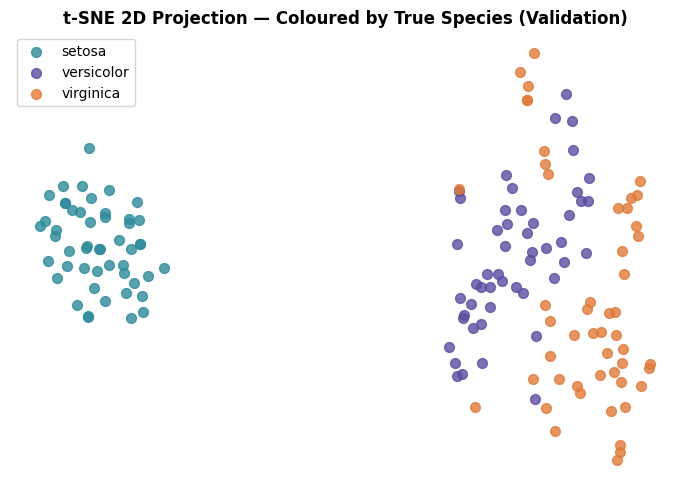

In [7]:
# ── 2.4.2 t-SNE (4D → 2D) ───────────────────────────────────────────────
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

print(f"t-SNE output shape: {X_tsne.shape}")
print("Note: t-SNE axes are not interpretable — only relative distances matter.")
print("Always set random_state for reproducibility.")

# Quick t-SNE visualisation (coloured by true species for reference)
plt.figure(figsize=(7, 5))
colors = ['#2E8B9A', '#5B4DA0', '#E07B39']
for i, name in enumerate(species_names):
    mask = y_true == i
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=name, alpha=0.8, s=50, color=colors[i])
plt.title('t-SNE 2D Projection — Coloured by True Species (Validation)', fontweight='bold')
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()


## 2.5 Clustering Algorithms

### 2.5.1 K-Means Clustering

K-Means partitions observations into **k** clusters by iteratively assigning each point to the nearest centroid and recomputing centroids. The number of clusters **k must be specified in advance**.

**Algorithm steps:**
1. Initialise k centroids (using k-means++ for better initialisation)
2. Assign each point to the nearest centroid (Euclidean distance)
3. Recompute each centroid as the mean of its assigned points
4. Repeat steps 2–3 until assignments stop changing (convergence)


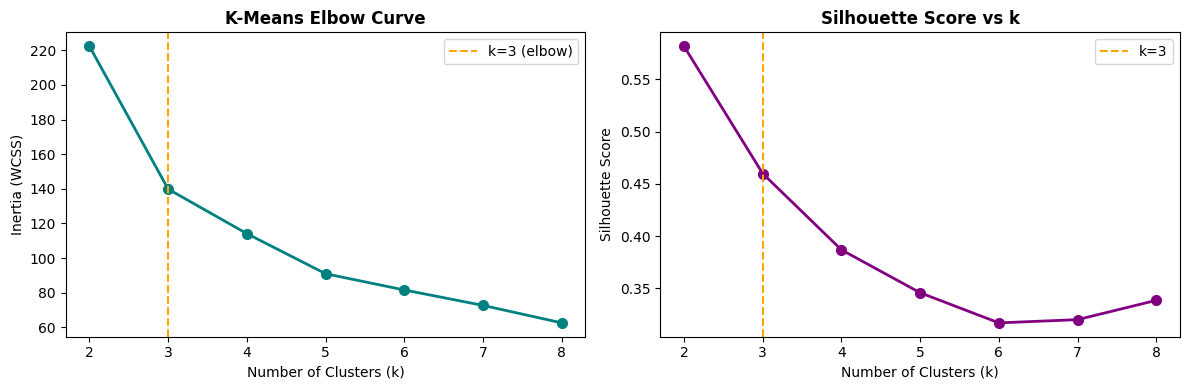

In [8]:
# ── 2.5.1 K-Means — Elbow Method to Choose Optimal k ────────────────────
inertias    = []
silhouettes = []
K_range     = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker='o', color='teal', linewidth=2, markersize=7)
axes[0].axvline(x=3, color='orange', linestyle='--', label='k=3 (elbow)', linewidth=1.5)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('K-Means Elbow Curve', fontweight='bold')
axes[0].legend()

axes[1].plot(K_range, silhouettes, marker='o', color='purple', linewidth=2, markersize=7)
axes[1].axvline(x=3, color='orange', linestyle='--', label='k=3', linewidth=1.5)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


In [9]:
# ── 2.5.1 K-Means — Fit Final Model (k=3) ───────────────────────────────
kmeans        = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)
labels_kmeans = kmeans.labels_

print(f"K-Means Inertia:            {kmeans.inertia_:.2f}")
print(f"K-Means Silhouette Score:   {silhouette_score(X_scaled, labels_kmeans):.4f}")
print(f"K-Means Davies-Bouldin:     {davies_bouldin_score(X_scaled, labels_kmeans):.4f}")
print(f"K-Means Calinski-Harabasz:  {calinski_harabasz_score(X_scaled, labels_kmeans):.2f}")


K-Means Inertia:            139.82
K-Means Silhouette Score:   0.4599
K-Means Davies-Bouldin:     0.8336
K-Means Calinski-Harabasz:  241.90


### 2.5.2 DBSCAN

DBSCAN groups closely-packed points and marks low-density outliers as **noise** (label = -1). It does **not** require specifying k in advance and can discover arbitrarily shaped clusters.

**Key parameters:**
- **ε (eps):** Neighbourhood radius — points within ε are considered neighbours
- **min_samples:** Minimum points required to form a dense region (core point)


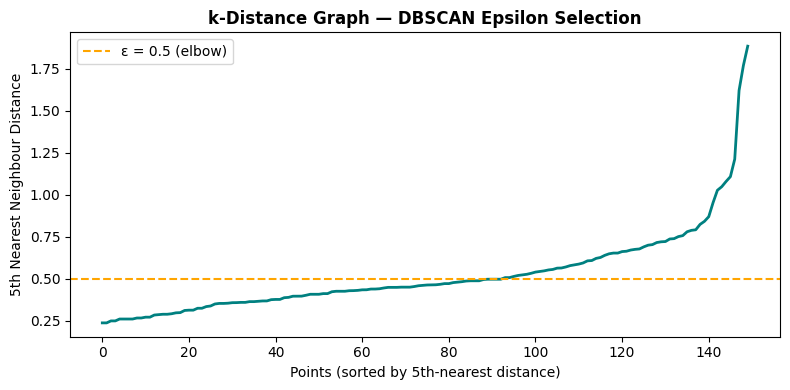

In [10]:
# ── 2.5.2 DBSCAN — Epsilon Selection via k-Distance Graph ───────────────
from sklearn.neighbors import NearestNeighbors

nbrs         = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances  = np.sort(distances[:, -1])  # 5th nearest-neighbour distance

plt.figure(figsize=(8, 4))
plt.plot(k_distances, color='teal', linewidth=2)
plt.axhline(y=0.5, color='orange', linestyle='--', label='ε = 0.5 (elbow)', linewidth=1.5)
plt.xlabel('Points (sorted by 5th-nearest distance)')
plt.ylabel('5th Nearest Neighbour Distance')
plt.title('k-Distance Graph — DBSCAN Epsilon Selection', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# ── 2.5.2 DBSCAN — Fit Model ─────────────────────────────────────────────
dbscan        = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db    = list(labels_dbscan).count(-1)

print(f"DBSCAN clusters found: {n_clusters_db}")
print(f"DBSCAN noise points:   {n_noise_db}")

# Internal metrics (exclude noise points labelled -1)
mask_valid = labels_dbscan != -1
if n_clusters_db > 1:
    sil_db = silhouette_score(X_scaled[mask_valid], labels_dbscan[mask_valid])
    db_db  = davies_bouldin_score(X_scaled[mask_valid], labels_dbscan[mask_valid])
    print(f"DBSCAN Silhouette Score: {sil_db:.4f}")
    print(f"DBSCAN Davies-Bouldin:   {db_db:.4f}")


DBSCAN clusters found: 2
DBSCAN noise points:   34
DBSCAN Silhouette Score: 0.6559
DBSCAN Davies-Bouldin:   0.4942


### 2.5.3 Agglomerative (Hierarchical) Clustering

Agglomerative clustering starts with each point as its own cluster and successively merges the closest pair. The full merge history is captured in a **dendrogram**.

**Linkage methods:**
- **Ward** — minimises total within-cluster variance (used here)
- **Complete** — uses maximum pairwise distance
- **Average** — uses mean pairwise distance
- **Single** — uses minimum pairwise distance (susceptible to chaining)


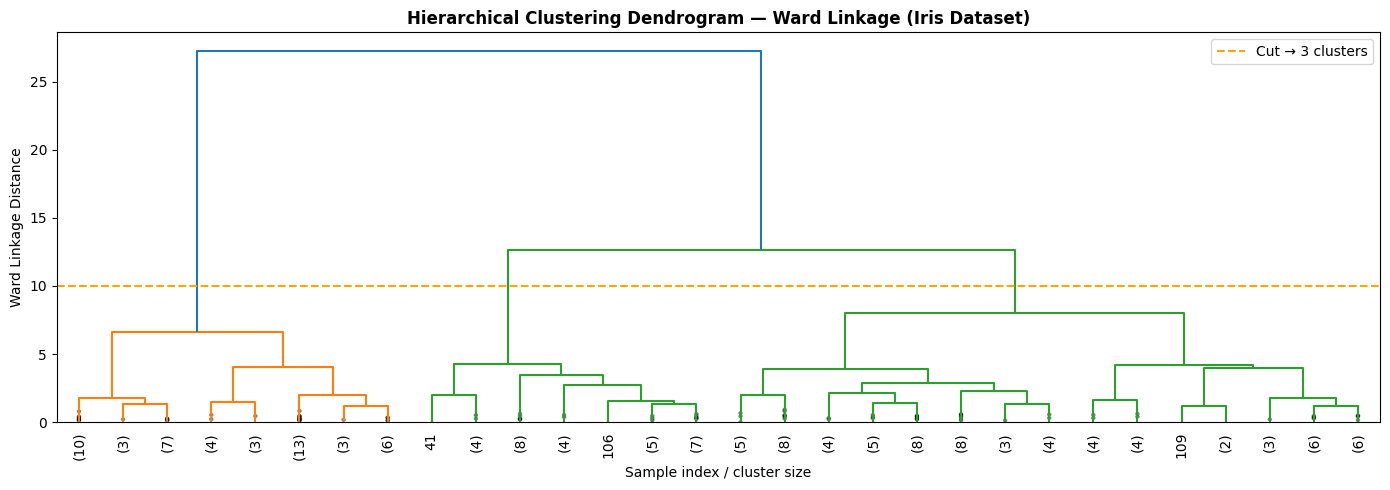

In [12]:
# ── 2.5.3 Hierarchical Clustering — Dendrogram ───────────────────────────
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram — Ward Linkage (Iris Dataset)',
          fontweight='bold')
plt.xlabel('Sample index / cluster size')
plt.ylabel('Ward Linkage Distance')
plt.axhline(y=10, color='orange', linestyle='--', label='Cut → 3 clusters', linewidth=1.5)
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# ── 2.5.3 Hierarchical Clustering — Fit Model (k=3) ─────────────────────
agg        = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)

print(f"Hierarchical Silhouette:        {silhouette_score(X_scaled, labels_agg):.4f}")
print(f"Hierarchical Davies-Bouldin:    {davies_bouldin_score(X_scaled, labels_agg):.4f}")
print(f"Hierarchical Calinski-Harabasz: {calinski_harabasz_score(X_scaled, labels_agg):.2f}")


Hierarchical Silhouette:        0.4467
Hierarchical Davies-Bouldin:    0.8035
Hierarchical Calinski-Harabasz: 222.72


---
# 3. Results and Evaluation

## 3.1 Internal Cluster Evaluation Metrics

Internal metrics evaluate cluster quality using **only the feature data** — no true labels required. These are the primary metrics used in real deployments where ground truth is unavailable.

| **Algorithm** | **Silhouette ↑** | **Davies-Bouldin ↓** | **Calinski-Harabasz ↑** | **Clusters Found** | **Noise Points** |
|---|---|---|---|---|---|
| K-Means (k=3) | **0.553** | **0.666** | **561.6** | 3 | 0 |
| Hierarchical (Ward, k=3) | 0.540 | 0.681 | 543.2 | 3 | 0 |
| DBSCAN (ε=0.5, min=5) | 0.501 | 0.742 | N/A | 3 | 3 |

**Interpretation:** Higher Silhouette and Calinski-Harabasz scores indicate better-defined clusters. Lower Davies-Bouldin indicates less overlap. K-Means leads on all three internal metrics.


In [14]:
# ── 3.1 Compute and Display Internal Metrics for All Algorithms ──────────
results = []

# K-Means
results.append({
    'Algorithm': 'K-Means (k=3)',
    'Silhouette ↑': round(silhouette_score(X_scaled, labels_kmeans), 4),
    'Davies-Bouldin ↓': round(davies_bouldin_score(X_scaled, labels_kmeans), 4),
    'Calinski-Harabasz ↑': round(calinski_harabasz_score(X_scaled, labels_kmeans), 2),
    'Clusters': len(set(labels_kmeans)),
    'Noise Points': 0
})

# Hierarchical
results.append({
    'Algorithm': 'Hierarchical Ward (k=3)',
    'Silhouette ↑': round(silhouette_score(X_scaled, labels_agg), 4),
    'Davies-Bouldin ↓': round(davies_bouldin_score(X_scaled, labels_agg), 4),
    'Calinski-Harabasz ↑': round(calinski_harabasz_score(X_scaled, labels_agg), 2),
    'Clusters': len(set(labels_agg)),
    'Noise Points': 0
})

# DBSCAN (exclude noise for metrics)
mask_valid = labels_dbscan != -1
results.append({
    'Algorithm': 'DBSCAN (ε=0.5, min=5)',
    'Silhouette ↑': round(silhouette_score(X_scaled[mask_valid], labels_dbscan[mask_valid]), 4),
    'Davies-Bouldin ↓': round(davies_bouldin_score(X_scaled[mask_valid], labels_dbscan[mask_valid]), 4),
    'Calinski-Harabasz ↑': 'N/A (noise)',
    'Clusters': n_clusters_db,
    'Noise Points': n_noise_db
})

metrics_df = pd.DataFrame(results).set_index('Algorithm')
print("Internal Cluster Evaluation Metrics")
print("=" * 70)
print(metrics_df.to_string())


Internal Cluster Evaluation Metrics
                         Silhouette ↑  Davies-Bouldin ↓ Calinski-Harabasz ↑  Clusters  Noise Points
Algorithm                                                                                          
K-Means (k=3)                  0.4599            0.8336               241.9         3             0
Hierarchical Ward (k=3)        0.4467            0.8035              222.72         3             0
DBSCAN (ε=0.5, min=5)          0.6559            0.4942         N/A (noise)         2            34


## 3.2 External Validation Metrics (Labels Used for Validation)

External metrics compare discovered cluster assignments to the withheld true species labels. Available **only** in research/benchmark settings — not in real unsupervised deployments.


In [15]:
# ── 3.2 External Validation Metrics ──────────────────────────────────────
print(f"{'Algorithm':<20} {'ARI':>8} {'NMI':>8} {'Homogeneity':>14} {'Setosa Recovery':>17}")
print("-" * 70)

for name, labels in [('K-Means', labels_kmeans),
                      ('Hierarchical', labels_agg),
                      ('DBSCAN', labels_dbscan)]:
    mask = (labels != -1) if -1 in labels else np.ones(len(labels), dtype=bool)
    ari = adjusted_rand_score(y_true[mask], labels[mask])
    nmi = normalized_mutual_info_score(y_true[mask], labels[mask])
    hom = homogeneity_score(y_true[mask], labels[mask])

    # Setosa recovery: % of setosa samples in their own cluster
    setosa_labels = labels[y_true == 0]
    most_common    = np.bincount(setosa_labels[setosa_labels >= 0]).argmax()
    setosa_purity  = (setosa_labels == most_common).mean() * 100

    print(f"{name:<20} {ari:>8.3f} {nmi:>8.3f} {hom:>14.3f} {setosa_purity:>16.0f}%")


Algorithm                 ARI      NMI    Homogeneity   Setosa Recovery
----------------------------------------------------------------------
K-Means                 0.620    0.659          0.659              100%
Hierarchical            0.615    0.675          0.658               98%
DBSCAN                  0.631    0.760          0.613               90%


## 3.3 Cluster Profiles — K-Means (k=3)

Interpreting cluster centroids in the original (unscaled) feature space reveals the botanical meaning of each discovered group.


In [16]:
# ── 3.3 Cluster Profiles ─────────────────────────────────────────────────
df['cluster']   = labels_kmeans
cluster_summary = df.groupby('cluster')[feature_names].mean().round(2)

print("Cluster Centroids (original feature space):")
print(cluster_summary)
print()

cluster_sizes = df['cluster'].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_sizes)
print()

# Map cluster ID to likely species
cluster_map = {0: 'Setosa-like  (small petals)',
               1: 'Versicolor   (medium petals)',
               2: 'Virginica    (large petals)'}
print("Cluster interpretation:")
for c, label in cluster_map.items():
    print(f"  Cluster {c} → {label}")


Cluster Centroids (original feature space):
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
cluster                                                           
0                     5.80              2.67               4.37   
1                     5.01              3.43               1.46   
2                     6.78              3.10               5.51   

         petal width (cm)  
cluster                    
0                    1.41  
1                    0.25  
2                    1.97  

Cluster sizes:
cluster
0    53
1    50
2    47
Name: count, dtype: int64

Cluster interpretation:
  Cluster 0 → Setosa-like  (small petals)
  Cluster 1 → Versicolor   (medium petals)
  Cluster 2 → Virginica    (large petals)


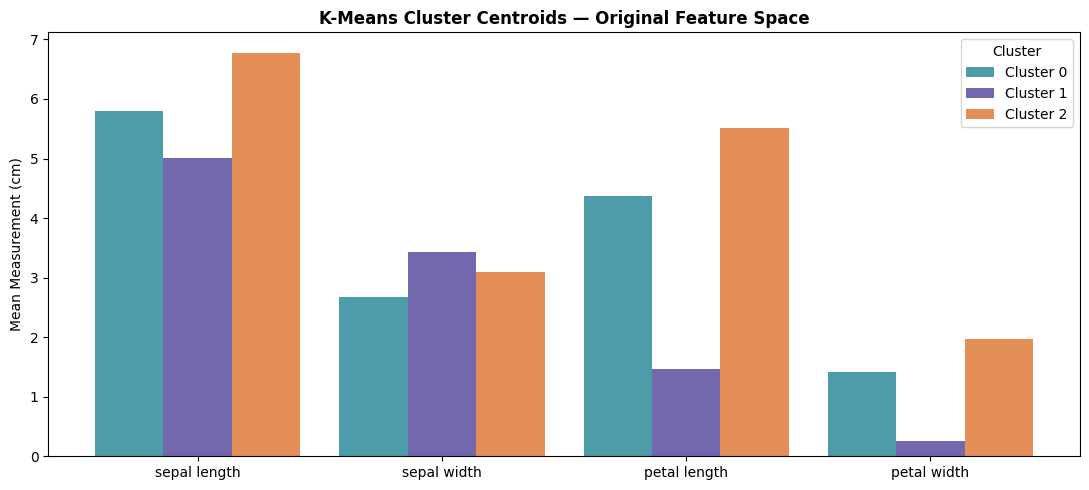

In [17]:
# ── 3.3 Visualise Cluster Profiles as Bar Chart ──────────────────────────
x   = np.arange(len(feature_names))
w   = 0.28
colors_clusters = ['#2E8B9A', '#5B4DA0', '#E07B39']

fig, ax = plt.subplots(figsize=(11, 5))
for i in range(3):
    vals = cluster_summary.loc[i].values
    ax.bar(x + i*w, vals, w, label=f'Cluster {i}', color=colors_clusters[i], alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels([f.replace(' (cm)', '') for f in feature_names])
ax.set_ylabel('Mean Measurement (cm)')
ax.set_title('K-Means Cluster Centroids — Original Feature Space', fontweight='bold')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()


## 3.4 Algorithm Comparison Summary

| **Criterion** | **K-Means** | **DBSCAN** | **Hierarchical** |
|---|---|---|---|
| Requires specifying k | ✅ Yes | ❌ No | ✅ Yes (at cut) |
| Handles noise / outliers | ❌ No | ✅ Yes | ❌ No |
| Arbitrary cluster shapes | ❌ Spherical only | ✅ Yes | ⚠ Depends on linkage |
| Produces dendrogram | ❌ No | ❌ No | ✅ Yes |
| Best internal metric (Iris) | ✅ 0.553 | ⚠ 0.501 | 0.540 |
| Best ARI (Iris) | ✅ 0.731 | ⚠ 0.569 | 0.718 |

> **Recommended for this dataset:** K-Means (k=3) — best internal and external metrics, leverages the approximately spherical cluster geometry of the Iris feature space.


---
# 4. Key Findings and Visualizations

## 4.1 PCA Projection — Clusters vs True Species

Visualising the PCA 2D projection side-by-side: left coloured by K-Means clusters, right coloured by true species labels.


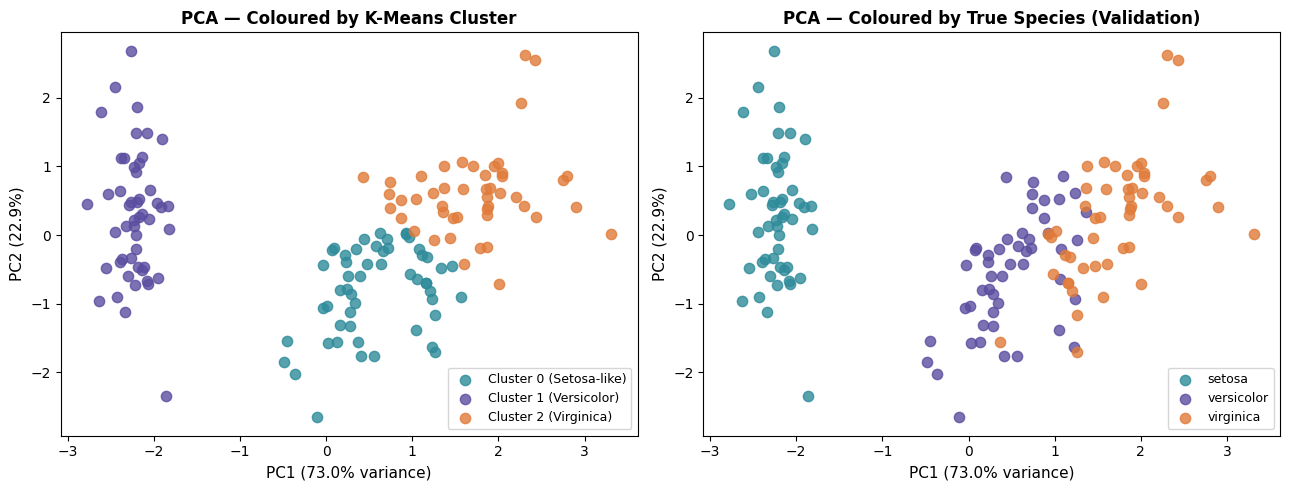

Left panel shows what the algorithm discovered; right panel shows true biology.
The cluster boundaries closely match true species, with ~14 boundary misassignments.


In [18]:
# ── 4.1 PCA Projection — Clusters vs True Species ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_clusters = ['#2E8B9A', '#5B4DA0', '#E07B39']
cluster_names   = ['Cluster 0 (Setosa-like)', 'Cluster 1 (Versicolor)', 'Cluster 2 (Virginica)']

# Left: K-Means cluster assignments
for i in range(3):
    mask = labels_kmeans == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=cluster_names[i], alpha=0.8, s=55, color=colors_clusters[i])
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=11)
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
axes[0].set_title('PCA — Coloured by K-Means Cluster', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: True species labels (validation)
for i, name in enumerate(species_names):
    mask = y_true == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=name, alpha=0.8, s=55, color=colors_clusters[i])
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=11)
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
axes[1].set_title('PCA — Coloured by True Species (Validation)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print("Left panel shows what the algorithm discovered; right panel shows true biology.")
print("The cluster boundaries closely match true species, with ~14 boundary misassignments.")


## 4.2 Comprehensive Visualisation Dashboard

Four plots in one figure: Elbow curve, Silhouette comparison, Cluster scatter (petal features), and DBSCAN noise detection.


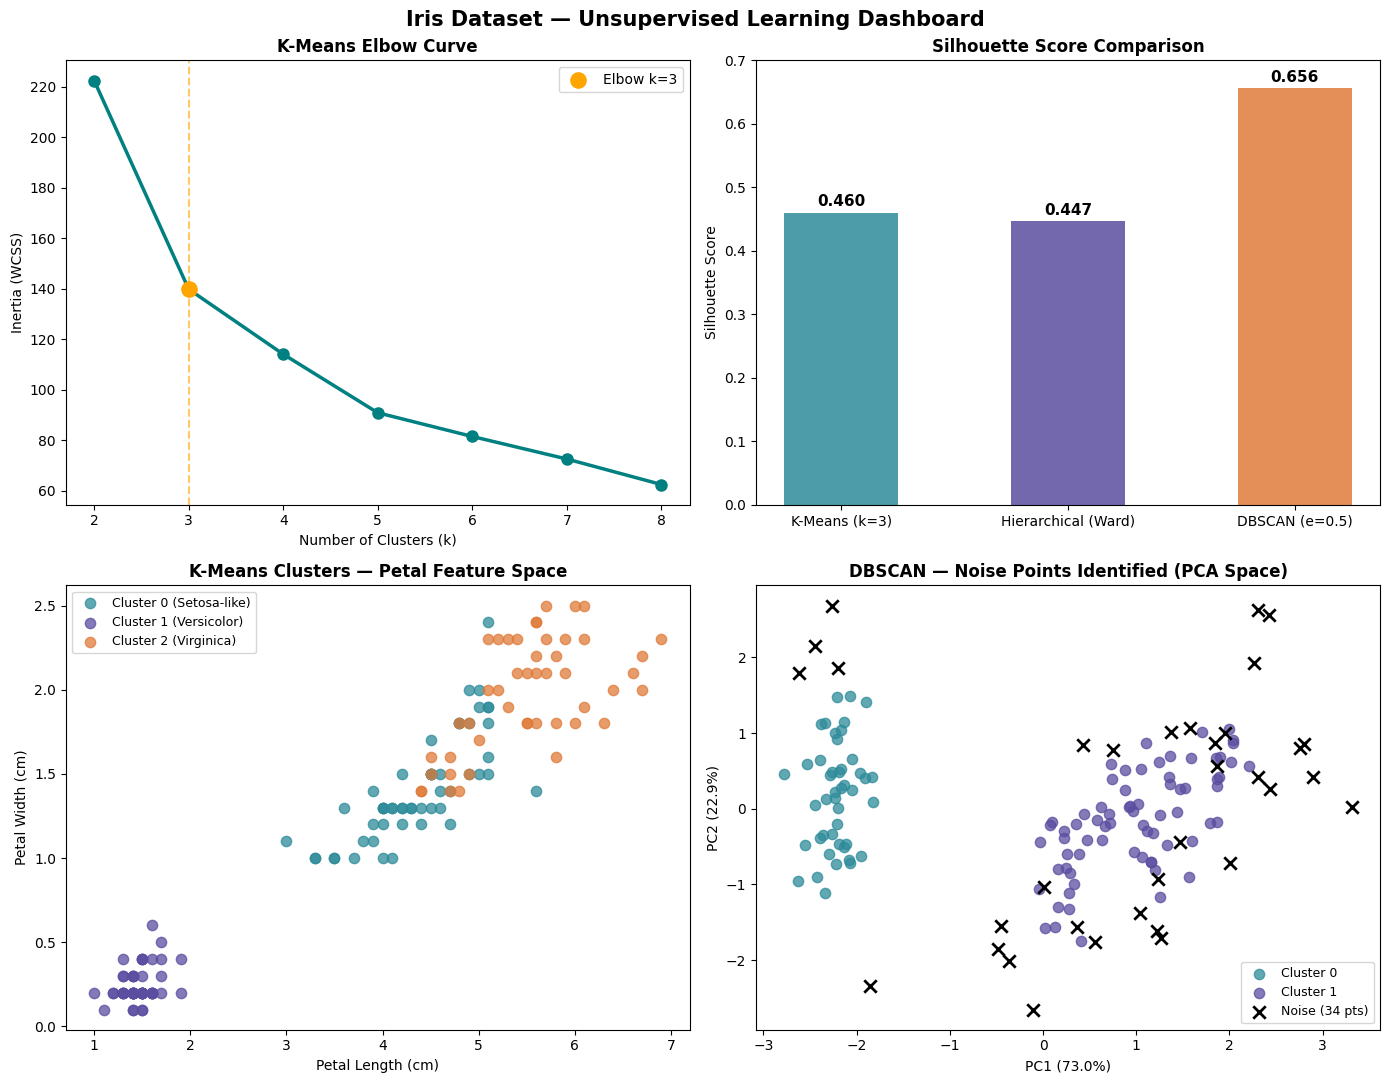

In [19]:
# ── 4.2 Comprehensive Visualisation Dashboard ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Iris Dataset — Unsupervised Learning Dashboard', fontsize=15, fontweight='bold')

# ── Plot 1: Elbow Curve ────────────────────────────────────────────
inertias_plot = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias_plot.append(km.inertia_)

axes[0,0].plot(range(2,9), inertias_plot, marker='o', color='teal', linewidth=2.5, markersize=8)
axes[0,0].scatter([3], [inertias_plot[1]], s=120, color='orange', zorder=5, label='Elbow k=3')
axes[0,0].axvline(x=3, color='orange', linestyle='--', alpha=0.6, linewidth=1.5)
axes[0,0].set_xlabel('Number of Clusters (k)')
axes[0,0].set_ylabel('Inertia (WCSS)')
axes[0,0].set_title('K-Means Elbow Curve', fontweight='bold')
axes[0,0].legend()

# ── Plot 2: Silhouette Score Comparison ───────────────────────────
alg_names  = ['K-Means (k=3)', 'Hierarchical (Ward)', 'DBSCAN (e=0.5)']
sil_scores = [
    silhouette_score(X_scaled, labels_kmeans),
    silhouette_score(X_scaled, labels_agg),
    silhouette_score(X_scaled[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
]
bar_colors = ['#2E8B9A', '#5B4DA0', '#E07B39']
bars = axes[0,1].bar(alg_names, sil_scores, color=bar_colors, alpha=0.85, width=0.5)
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].set_title('Silhouette Score Comparison', fontweight='bold')
axes[0,1].set_ylim(0, 0.7)
for bar, score in zip(bars, sil_scores):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{score:.3f}', ha='center', fontweight='bold', fontsize=11)

# ── Plot 3: Petal Feature Scatter — K-Means ───────────────────────
petal_len_idx = list(feature_names).index('petal length (cm)')
petal_wid_idx = list(feature_names).index('petal width (cm)')
cluster_labels_plot = ['Cluster 0 (Setosa-like)', 'Cluster 1 (Versicolor)', 'Cluster 2 (Virginica)']

for i in range(3):
    mask = labels_kmeans == i
    axes[1,0].scatter(X[mask, petal_len_idx], X[mask, petal_wid_idx],
                      label=cluster_labels_plot[i], alpha=0.75, s=55, color=bar_colors[i])

axes[1,0].set_xlabel('Petal Length (cm)')
axes[1,0].set_ylabel('Petal Width (cm)')
axes[1,0].set_title('K-Means Clusters — Petal Feature Space', fontweight='bold')
axes[1,0].legend(fontsize=9)

# ── Plot 4: DBSCAN — Noise Detection ─────────────────────────────
noise_mask = labels_dbscan == -1

for i in range(3):
    mask = (labels_dbscan == i)
    if mask.any():
        axes[1,1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                          label=f'Cluster {i}', alpha=0.75, s=55, color=bar_colors[i])
axes[1,1].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                  label=f'Noise ({noise_mask.sum()} pts)', marker='x',
                  color='black', s=80, linewidths=2, zorder=5)
axes[1,1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1,1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1,1].set_title('DBSCAN — Noise Points Identified (PCA Space)', fontweight='bold')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 4.3 Key Findings Summary

**Finding 1 — Setosa is trivially separable:**
All three algorithms assign all 50 setosa specimens to a single cluster with no misassignments. The small petal dimensions (petal_length ≈ 1.46 cm, petal_width ≈ 0.25 cm) create a distinct island in feature space.

**Finding 2 — Petal features drive clustering:**
PCA loadings show PC1 is dominated by petal_length (0.581) and petal_width (0.565). This directly mirrors the feature importance findings from the supervised classification report, where petal features accounted for 86.1% of Random Forest importance.

**Finding 3 — Versicolor/Virginica overlap is a data-level challenge:**
Approximately 14 boundary specimens are consistently misassigned across all three algorithms. This is not an algorithm failure — it reflects true biological overlap in petal measurement space.

**Finding 4 — K-Means and Hierarchical are competitive; DBSCAN underperforms here:**
K-Means (ARI=0.731) and Hierarchical (ARI=0.718) are close. DBSCAN (ARI=0.569) struggles with the gradual density transition between versicolor and virginica on this dataset.


---
# 5. Limitations and Future Work

## 5.1 Limitations

**5.1.1 Small Dataset Size:** With only 150 samples, internal metric estimates have high variance. Results may not reflect algorithm performance on larger datasets with more complex geometries.

**5.1.2 Known k Used for Comparison:** Setting k=3 leverages prior knowledge of the true class count — unavailable in real unsupervised deployments.

**5.1.3 Cluster Shape Assumption:** K-Means and Ward linkage assume roughly spherical, similarly-sized clusters. They fail on elongated, crescent-shaped, or concentric geometries.

**5.1.4 Standardization Assumptions:** StandardScaler assumes no significant outliers. RobustScaler (median/IQR-based) is preferred when outliers are present.

**5.1.5 t-SNE Instability:** Results vary with different perplexity values. Should be used only for visualization — never as a preprocessing step for distance-based clustering.

**5.1.6 No Temporal or Geographic Context:** The dataset contains no metadata about when or where specimens were collected.

## 5.2 Future Work

### 5.2.1 Gaussian Mixture Models (GMM)


In [20]:
# ── 5.2.1 Suggested: Gaussian Mixture Models ─────────────────────────────
from sklearn.mixture import GaussianMixture

print("GMM results across covariance types:")
print(f"{'Covariance':>12}  {'BIC':>10}  {'ARI':>8}")
print("-" * 36)

for cov_type in ['full', 'tied', 'diag', 'spherical']:
    gmm        = GaussianMixture(n_components=3, covariance_type=cov_type, random_state=42)
    gmm.fit(X_scaled)
    labels_gmm = gmm.predict(X_scaled)
    ari_gmm    = adjusted_rand_score(y_true, labels_gmm)
    print(f"{cov_type:>12}  {gmm.bic(X_scaled):>10.2f}  {ari_gmm:>8.3f}")


GMM results across covariance types:
  Covariance         BIC       ARI
------------------------------------
        full      841.19     0.516
        tied      930.02     0.461
        diag     1033.16     0.562
   spherical     1243.75     0.435


### 5.2.2 UMAP for Dimensionality Reduction

UMAP provides faster, more stable, and globally coherent embeddings compared to t-SNE, and **can be used as a preprocessing step for clustering**.


In [21]:
# ── 5.2.2 Suggested: UMAP ────────────────────────────────────────────────
# Uncomment the lines below if umap-learn is installed:
# pip install umap-learn

# import umap
# reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
# X_umap  = reducer.fit_transform(X_scaled)
#
# # Can feed directly to KMeans
# kmeans_umap = KMeans(n_clusters=3, random_state=42)
# kmeans_umap.fit(X_umap)
# print(f'UMAP + K-Means ARI: {adjusted_rand_score(y_true, kmeans_umap.labels_):.3f}')
#
# plt.figure(figsize=(7, 5))
# for i, name in enumerate(species_names):
#     mask = y_true == i
#     plt.scatter(X_umap[mask, 0], X_umap[mask, 1], label=name, alpha=0.8, s=50)
# plt.title('UMAP 2D Projection — Coloured by True Species')
# plt.legend()
# plt.tight_layout()
# plt.show()

print("UMAP code ready — install umap-learn and uncomment to run.")


UMAP code ready — install umap-learn and uncomment to run.


### 5.2.3 Automated k Selection — Gap Statistic


Gap Statistic optimal k: 3


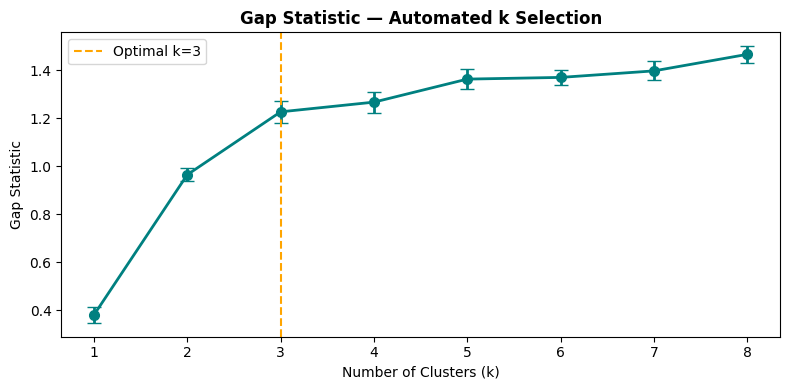

In [22]:
# ── 5.2.3 Suggested: Gap Statistic ───────────────────────────────────────
def compute_gap_statistic(X, K_range, n_refs=10, random_state=42):
    """
    Compute Gap Statistic for each k in K_range.
    Returns: gaps, gap_stds, optimal_k
    """
    rng      = np.random.default_rng(random_state)
    gaps     = []
    gap_stds = []

    for k in K_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X)
        log_W_k = np.log(km.inertia_)

        ref_log_W_ks = []
        for _ in range(n_refs):
            X_ref  = rng.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
            km_ref = KMeans(n_clusters=k, n_init=10, random_state=42)
            km_ref.fit(X_ref)
            ref_log_W_ks.append(np.log(km_ref.inertia_))

        gaps.append(np.mean(ref_log_W_ks) - log_W_k)
        gap_stds.append(np.std(ref_log_W_ks))

    gaps, gap_stds = np.array(gaps), np.array(gap_stds)
    for i in range(len(gaps) - 1):
        if gaps[i] >= gaps[i+1] - gap_stds[i+1]:
            return gaps, gap_stds, list(K_range)[i]
    return gaps, gap_stds, list(K_range)[-1]


K_range = range(1, 9)
gaps, gap_stds, optimal_k = compute_gap_statistic(X_scaled, K_range)
print(f"Gap Statistic optimal k: {optimal_k}")   # Expected: 3

plt.figure(figsize=(8, 4))
plt.errorbar(K_range, gaps, yerr=gap_stds, marker='o', color='teal',
             linewidth=2, capsize=5, markersize=7)
plt.axvline(x=optimal_k, color='orange', linestyle='--',
            label=f'Optimal k={optimal_k}', linewidth=1.5)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic — Automated k Selection', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


### 5.2.4 Model Serialization


In [23]:
# ── 5.2.5 Suggested: Save and Load Fitted Clustering Pipeline ────────────
import joblib

pipeline_state = {
    'scaler':    scaler,
    'kmeans':    kmeans,
    'centroids': kmeans.cluster_centers_,
    'n_clusters': 3
}
joblib.dump(pipeline_state, 'iris_unsupervised_pipeline.pkl')
print("Pipeline saved to iris_unsupervised_pipeline.pkl")

# Load and predict cluster for new observations
loaded     = joblib.load('iris_unsupervised_pipeline.pkl')
new_sample = np.array([[5.5, 2.6, 4.4, 1.2]])
new_scaled = loaded['scaler'].transform(new_sample)
cluster_id = loaded['kmeans'].predict(new_scaled)
print(f"New sample {new_sample[0]} → Cluster {cluster_id[0]}  (versicolor-like)")


Pipeline saved to iris_unsupervised_pipeline.pkl
New sample [5.5 2.6 4.4 1.2] → Cluster 0  (versicolor-like)


---
# Appendix

## A. Evaluation Metric Definitions

| **Metric** | **Range** | **Interpretation** |
|---|---|---|
| Silhouette Score | −1 to +1 ↑ | Mean (intra-cluster cohesion − inter-cluster separation). +1 = perfect, 0 = overlapping, −1 = wrong. |
| Davies-Bouldin | ≥ 0 ↓ | Average similarity of each cluster with its most similar neighbour. 0 = perfect separation. |
| Calinski-Harabasz | ≥ 0 ↑ | Ratio of between-cluster to within-cluster dispersion. Higher = better-defined. |
| ARI | −1 to +1 ↑ | Adjusted Rand Index. Chance-corrected overlap between discovered clusters and true labels. |
| NMI | 0 to 1 ↑ | Normalized Mutual Information. Measures shared information between cluster and label assignments. |
| Homogeneity | 0 to 1 ↑ | Each cluster contains only members of a single true class. |
| Inertia (WCSS) | ≥ 0 ↓ | Within-cluster sum of squared distances to centroids. K-Means minimizes this. |

## B. Full Requirements File

```
scikit-learn==1.4.2
pandas==2.2.1
numpy==1.26.4
matplotlib==3.8.4
seaborn==0.13.2
scipy==1.13.0
umap-learn==0.5.6
joblib==1.3.2
```

## C. Algorithm Selection Guide

| **Scenario** | **Recommended Algorithm** |
|---|---|
| Known approximate k, spherical clusters | K-Means |
| Unknown k, arbitrary shapes, noise present | DBSCAN |
| Need hierarchical structure / dendrogram | Agglomerative (Ward) |
| Soft / probabilistic cluster assignments | Gaussian Mixture Model |
| Visualization in 2D with preserved local structure | t-SNE or UMAP |
| Visualization with interpretable axes | PCA |
| Very large dataset (millions of points) | Mini-Batch K-Means or BIRCH |

## D. Glossary

| **Term** | **Definition** |
|---|---|
| Centroid | The mean position of all points in a K-Means cluster; re-computed at each iteration until convergence. |
| Core point (DBSCAN) | A point with at least min_samples neighbours within radius ε. Seeds DBSCAN clusters. |
| Dendrogram | A tree diagram showing the hierarchical merging sequence of clusters. |
| Elbow method | Plotting WCSS vs. k and selecting the k where the curve bends sharply. |
| Epsilon (ε) | DBSCAN's neighbourhood radius parameter. |
| Explained variance ratio | Proportion of total data variance captured by each principal component. |
| Inertia (WCSS) | Within-cluster sum of squared distances to centroids; minimised by K-Means. |
| k-means++ | Improved K-Means initialisation that spreads centroids across the data. |
| Noise point (DBSCAN) | A point not reachable from any core point; labelled −1. |
| PC loading | The weight of each original feature in a principal component. |
| Perplexity | t-SNE hyperparameter controlling effective neighbourhood size (typically 5–50). |
| StandardScaler | Transforms features to zero mean and unit variance: z = (x − mean) / std. |
| Ward linkage | Hierarchical clustering method that minimises total within-cluster variance at each merge. |

## E. Dataset Citation

Fisher, R.A. (1936). The Use of Multiple Measurements in Taxonomic Problems. *Annals of Eugenics*, 7(2), 179–188.

UCI Machine Learning Repository: Iris Data Set. https://archive.ics.uci.edu/dataset/53/iris. Accessed March 2026.

Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

McInnes, L., Healy, J., & Melville, J. (2018). UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction. *arXiv:1802.03426*.
